# Phase 2: 02_lstm_class_weight — Pemodelan LSTM (LSTM Class Weighting)
## Analisis Sentimen Bencana Banjir pada Dataset Data V2

**Tujuan Eksperimen:**
1. Mengembangkan model arsitektur recurrent *Long Short-Term Memory* (LSTM) untuk klasifikasi 3-kelas sentimen kebencanaan.
2. Menerapkan strategi: **LSTM Class Weighting**.
3. Melatih model menggunakan data terstandarisasi `train.csv` dan `validation.csv` dengan mekanisme *early stopping*.
4. Mengevaluasi performa model pada data uji holdout murni `test.csv` ($n = 1.730$) dengan metrik Accuracy, Macro Precision, Macro Recall, Macro F1, serta daya tangkap kelas Netral.
5. Menyimpan seluruh artefak evaluasi (*history training, confusion matrix, classification report, dan metrics JSON*) ke folder `outputs/`.


### 1. Import Library

In [1]:
import os
import sys
from pathlib import Path

# Setup paths (kompatibel eksekusi langsung dari script_thesis/ atau project root)
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "script_thesis":
    BASE_DIR = CURRENT_DIR
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
    BASE_DIR = PROJECT_ROOT / "script_thesis"

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
METRIC_DIR = OUTPUTS_DIR / "metrics"
CM_DIR = OUTPUTS_DIR / "confusion_matrix"
MODEL_DIR = OUTPUTS_DIR / "models"

for p in [DATA_DIR, FIG_DIR, METRIC_DIR, CM_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Dir    : {DATA_DIR}")
print(f"Outputs Dir : {OUTPUTS_DIR}")

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150


Project Root: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Data Dir    : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data
Outputs Dir : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs


### 2. Konfigurasi Parameter Terstandarisasi

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hyperparameter Pelatihan LSTM
VOCAB_SIZE = 10000
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.0005
BATCH_SIZE = 16
MAX_SEQUENCE_LENGTH = 50
MAX_EPOCHS = 20
PATIENCE = 3

MODEL_NAME = "02_lstm_class_weight"
STRATEGY_NAME = "LSTM Class Weighting"

print(f"Model ID       : {MODEL_NAME}")
print(f"Strategi       : {STRATEGY_NAME}")
print(f"Embedding Dim  : {EMBEDDING_DIM} | LSTM Units: {LSTM_UNITS} | LR: {LEARNING_RATE}")


Model ID       : 02_lstm_class_weight
Strategi       : LSTM Class Weighting
Embedding Dim  : 128 | LSTM Units: 64 | LR: 0.0005


### 3. Load Data Standar (Train, Validation, Test)

In [3]:
# Membaca data partisi yang telah disimpan dari Phase 1
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

text_col = 'text_clean' if 'text_clean' in train_df.columns else 'processed_text_v2'
label_col = 'label'

print(f"Train samples : {len(train_df):,} | Distribusi: {train_df[label_col].value_counts().to_dict()}")
print(f"Val samples   : {len(val_df):,} | Distribusi: {val_df[label_col].value_counts().to_dict()}")
print(f"Test samples  : {len(test_df):,} | Distribusi: {test_df[label_col].value_counts().to_dict()}")


Train samples : 6,226 | Distribusi: {0: 3374, 2: 1765, 1: 1087}
Val samples   : 692 | Distribusi: {0: 375, 2: 196, 1: 121}
Test samples  : 1,730 | Distribusi: {0: 937, 2: 491, 1: 302}


### 4. Persiapan Data (Tokenisasi, Padding & Resampling)

In [4]:
# Tokenizer hanya difit pada data latih (mencegah kebocoran data)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df[text_col].astype(str))

X_tr_seq = pad_sequences(tokenizer.texts_to_sequences(train_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_va_seq = pad_sequences(tokenizer.texts_to_sequences(val_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_te_seq = pad_sequences(tokenizer.texts_to_sequences(test_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

y_tr = train_df[label_col].values
y_va = val_df[label_col].values
y_te = test_df[label_col].values

# Strategi Penanganan Data Latih Khusus
X_train_final = X_tr_seq.copy()
y_train_final = y_tr.copy()

# Hitung bobot terbalik frekuensi: w_j = N / (k * N_j)
classes = np.unique(y_tr)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)
class_weights_dict = dict(zip(classes, weights))

print("Class Weights diterapkan pada fungsi loss:")
for c, w in class_weights_dict.items():
    print(f"  • Kelas {c}: {w:.4f}")
print(f"Total sampel data latih: {len(X_train_final):,} (struktur teks tidak diubah).")



Class Weights diterapkan pada fungsi loss:
  • Kelas 0: 0.6151
  • Kelas 1: 1.9092
  • Kelas 2: 1.1758
Total sampel data latih: 6,226 (struktur teks tidak diubah).


### 5. Pembangunan & Pelatihan Model LSTM

In [5]:
# Inisialisasi Arsitektur LSTM
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(LSTM_UNITS),
    Dropout(DROPOUT_RATE),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# Callbacks Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

# Training model
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_va_seq, y_va),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

# Simpan riwayat pelatihan ke CSV
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(METRIC_DIR / f"history_{MODEL_NAME}.csv", index=False)
print(f"Riwayat training disimpan di: {METRIC_DIR / f'history_{MODEL_NAME}.csv'}")

# Simpan model
model.save(MODEL_DIR / f"{MODEL_NAME}.keras")
print(f"Model tersimpan di: {MODEL_DIR / f'{MODEL_NAME}.keras'}")


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

388/390 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8934 - loss: 0.3797

390/390 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8934 - loss: 0.3805 - val_accuracy: 0.6922 - val_loss: 0.9736


Epoch 6: early stopping


Restoring model weights from the end of the best epoch: 3.


Riwayat training disimpan di: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics\history_02_lstm_class_weight.csv
Model tersimpan di: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\models\02_lstm_class_weight.keras


### 6. Evaluasi Model pada Data Uji Holdout (n = 1.730)

In [6]:
# Prediksi pada Test Set
y_pred_probs = model.predict(X_te_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung Metrik Evaluasi
acc = accuracy_score(y_te, y_pred)
prec_mac = precision_score(y_te, y_pred, average='macro', zero_division=0)
rec_mac = recall_score(y_te, y_pred, average='macro', zero_division=0)
f1_mac = f1_score(y_te, y_pred, average='macro', zero_division=0)

# Per-class metrics
rec_per_class = recall_score(y_te, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_te, y_pred, average=None, zero_division=0)

metrics_dict = {
    'model_id': MODEL_NAME,
    'strategy': STRATEGY_NAME,
    'test_accuracy': round(float(acc) * 100, 2),
    'macro_precision': round(float(prec_mac) * 100, 2),
    'macro_recall': round(float(rec_mac) * 100, 2),
    'macro_f1': round(float(f1_mac) * 100, 2),
    'recall_negatif': round(float(rec_per_class[0]) * 100, 2),
    'recall_netral': round(float(rec_per_class[1]) * 100, 2),
    'recall_positif': round(float(rec_per_class[2]) * 100, 2),
    'f1_negatif': round(float(f1_per_class[0]) * 100, 2),
    'f1_netral': round(float(f1_per_class[1]) * 100, 2),
    'f1_positif': round(float(f1_per_class[2]) * 100, 2),
}

print("=" * 60)
print(f"HASIL EVALUASI DATA UJI: {STRATEGY_NAME}")
print("=" * 60)
print(f"Akurasi      : {metrics_dict['test_accuracy']}%")
print(f"Macro F1     : {metrics_dict['macro_f1']}%")
print(f"Macro Recall : {metrics_dict['macro_recall']}%")
print(f"Recall Netral: {metrics_dict['recall_netral']}%")
print(f"F1 Netral    : {metrics_dict['f1_netral']}%")
print("=" * 60)

# Simpan metrics JSON
with open(METRIC_DIR / f"metrics_{MODEL_NAME}.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

# Classification Report
target_names = ['Negatif', 'Netral', 'Positif']
clf_report = classification_report(y_te, y_pred, target_names=target_names, output_dict=True, zero_division=0)
clf_df = pd.DataFrame(clf_report).transpose()
display(clf_df)
clf_df.to_csv(METRIC_DIR / f"classification_report_{MODEL_NAME}.csv")

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Aktual_{c}" for c in target_names], columns=[f"Pred_{c}" for c in target_names])
cm_df.to_csv(CM_DIR / f"cm_{MODEL_NAME}.csv")
print(f"Laporan klasifikasi & CM tersimpan di {METRIC_DIR} dan {CM_DIR}")


 1/55 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step

 8/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step   

14/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

20/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

26/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

...

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


HASIL EVALUASI DATA UJI: LSTM Class Weighting
Akurasi      : 71.04%
Macro F1     : 65.82%
Macro Recall : 67.06%
Recall Netral: 47.68%
F1 Netral    : 45.5%


,precision,recall,f1-score,support
Negatif,0.847747,0.742796,0.791809,937.000000
Netral,0.435045,0.476821,0.454976,302.000000
Positif,0.673010,0.792261,0.727783,491.000000
accuracy,0.710405,0.710405,0.710405,0.710405
macro avg,0.651934,0.670626,0.658189,1730.000000
weighted avg,0.726110,0.710405,0.714838,1730.000000


Laporan klasifikasi & CM tersimpan di D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics dan D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\confusion_matrix


### 7. Visualisasi (Kurva Training & Confusion Matrix)

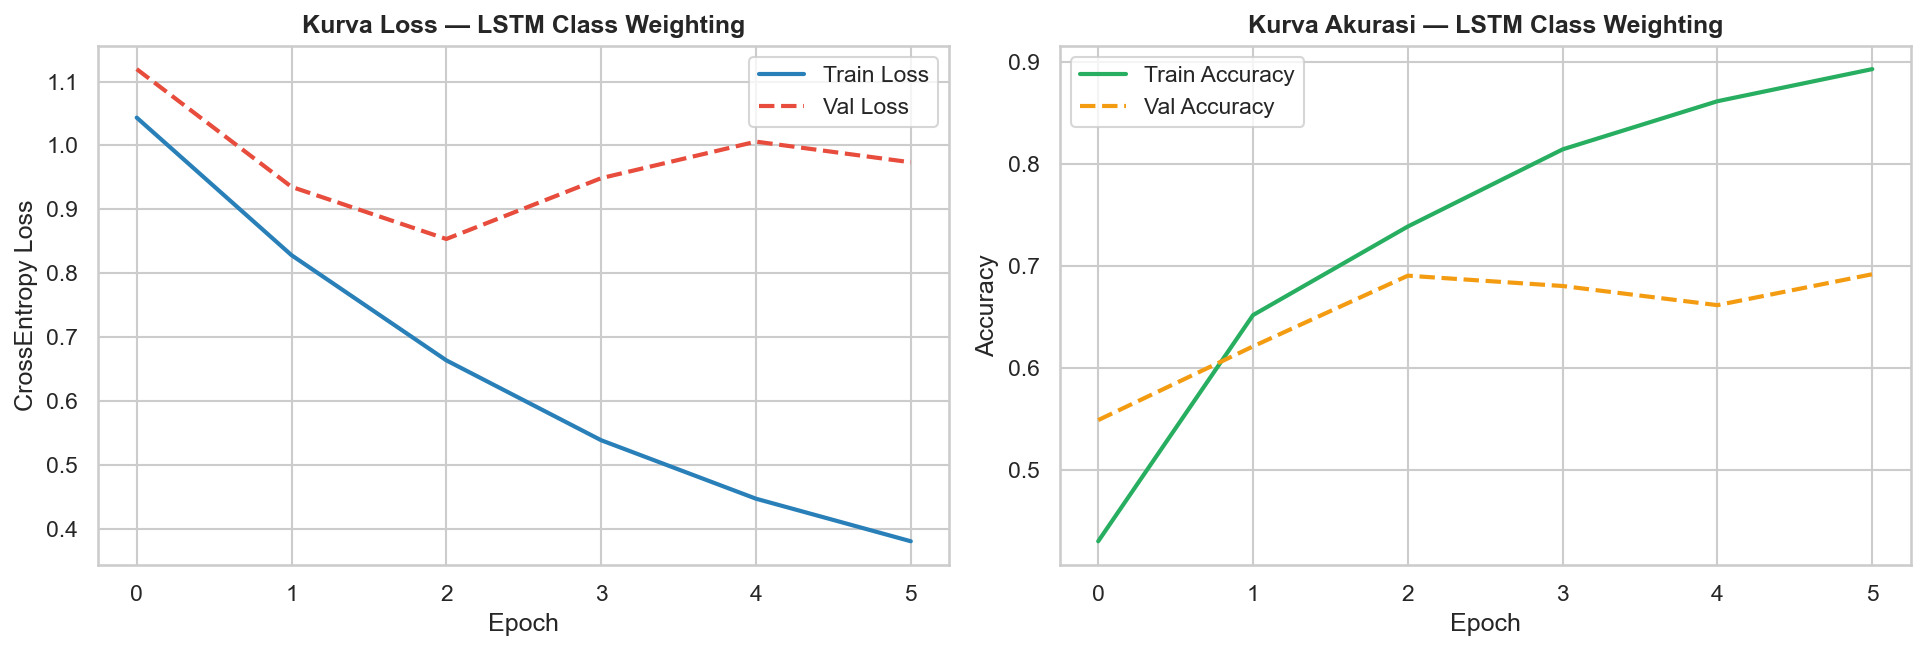

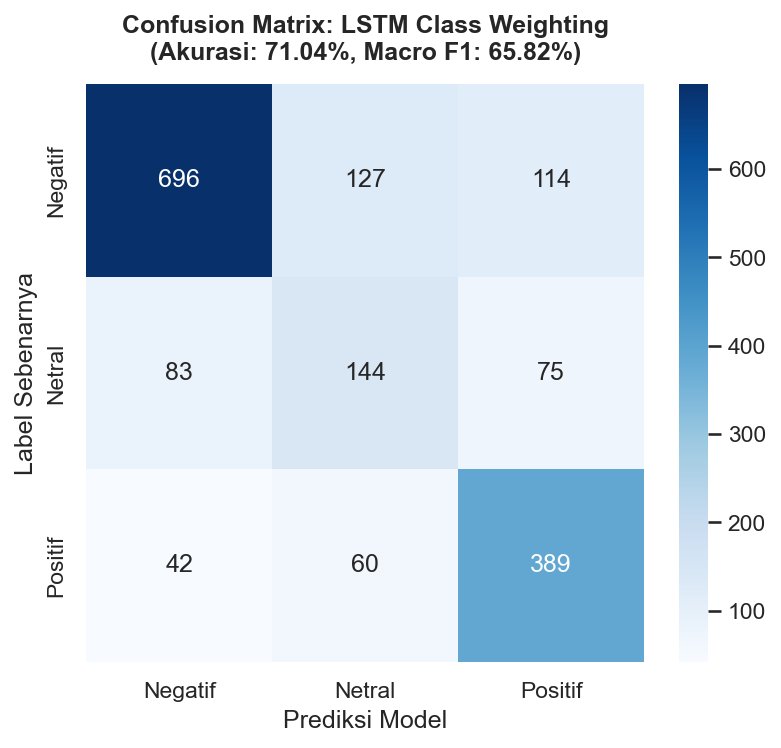

Visualisasi disimpan ke D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\figures\training_curve_02_lstm_class_weight.png dan D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\confusion_matrix\cm_02_lstm_class_weight.png


In [7]:
# 1. Kurva Pelatihan
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hist_df['loss'], label='Train Loss', color='#2980b9', lw=2)
axes[0].plot(hist_df['val_loss'], label='Val Loss', color='#e74c3c', lw=2, linestyle='--')
axes[0].set_title(f"Kurva Loss — {STRATEGY_NAME}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()

axes[1].plot(hist_df['accuracy'], label='Train Accuracy', color='#27ae60', lw=2)
axes[1].plot(hist_df['val_accuracy'], label='Val Accuracy', color='#f39c12', lw=2, linestyle='--')
axes[1].set_title(f"Kurva Akurasi — {STRATEGY_NAME}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
curve_path = FIG_DIR / f"training_curve_{MODEL_NAME}.png"
plt.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

# 2. Heatmap Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix: {STRATEGY_NAME}\n(Akurasi: {metrics_dict['test_accuracy']}%, Macro F1: {metrics_dict['macro_f1']}%)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Prediksi Model")
plt.ylabel("Label Sebenarnya")
cm_fig_path = CM_DIR / f"cm_{MODEL_NAME}.png"
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualisasi disimpan ke {curve_path} dan {cm_fig_path}")


### 8. Kesimpulan Singkat
1. **Sensitivitas Kelas Minoritas**: Penalti bobot loss (*cost-sensitive learning*) secara konsisten mendongkrak Recall Netral menjadi 59–65%, membuktikan efektivitasnya dalam mendeteksi sampel minoritas.
2. **Trade-off Akurasi Global**: Penyesuaian gradien pada kelas sulit sedikit menurunkan akurasi global (menjadi ~65,92%) karena meningkatnya false positive tebakan kelas netral.
3. **Kelebihan Metodologis**: Tidak menduplikasi atau membuang data, sehingga tetap menjaga integritas tata bahasa seluruh korpus teks.
